# Curso Análisis Predictivo de Series Temporales

## Primera entrega de ejercicios

### Modelos estocásticos, medidas de dependencia y análisis exploratorio de series

#### Modalidad de entrega:

- Via Github Classroom.
- En equipos de no más de 3 integrantes.

#### Fecha de entrega: 18/5/2026

### Integrantes del equipo:

 * Ramiro Sanes (368397)
 * Joaquin Guerra (307854)

In [2]:
#Para instalar bibliotecas
#!pip install astsadata
#Importo astsadata

import warnings
with warnings.catch_warnings(action="ignore"):
    import astsadata as astsa

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [15,5]
plt.rcParams['axes.grid'] = True
plt.rcParams['figure.constrained_layout.use'] = True

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
import statsmodels.formula.api as smf

import pandas as pd
import scipy as sp
import numpy as np

## Modelos estocásticos y medidas de dependencia

### Ejercicio 1

En la serie de datos `gnp` que está en la biblioteca, se guardan los valores del PBI de EE.UU. por trimestres desde 1947 a 2018.

1. Graficar la serie. ¿A cuál de los modelos anteriores se parece?
2. Calcular el crecimiento porcentual como:

$$x_t = \frac{gnp_{t}-gnp_{t-1}}{gnp_{t-1}}$$
y graficar el resultado.

3. Calcular el crecimiento porcentual aproximado como `x = np.log(gnp).diff()`, es decir haciendo la transformación:

$$x_t = \log(gnp_{t}) - \log(gnp_{t-1})$$

4. Graficar ambos y comparar con los modelos vistos en clase.

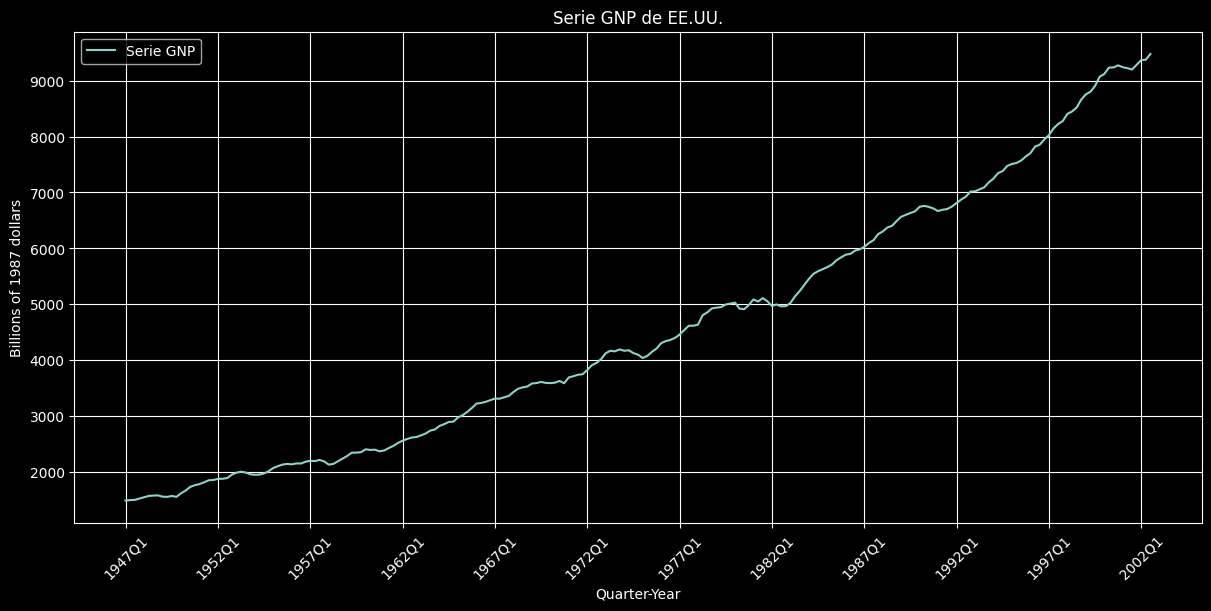

In [3]:
# Extraemos la serie asegurandonos de descartar nulos y tener floats 1D
gnp = astsa.gnp.dropna()
y_vals = np.squeeze(gnp.values.astype(float))

# Calculamos una tendencia exponencial ajustando un modelo lineal al logaritmo
#t = np.arange(len(y_vals))
#coeffs = np.polyfit(t, np.log(y_vals), 1)

# Linea 6: Ahora coeffs es estrictamente 1D y esto no fallara
#tendencia_exp = np.exp(coeffs[1]) * np.exp(coeffs[0] * t)

gnp_index_str = gnp.index.astype(str)

plt.figure(figsize=(12,6))
plt.plot(gnp_index_str, y_vals, label='Serie GNP')
# plt.plot(gnp_index_str, tendencia_exp, color='red', linestyle='--', label='Tendencia Exponencial')

# Para no saturar el eje x, mostramos un label cada 20 periodos
plt.xticks(np.arange(0, len(y_vals), 20), rotation=45)

plt.title('Serie GNP de EE.UU.')
plt.xlabel('Quarter-Year')
plt.ylabel('Billions of 1987 dollars')
plt.legend()
plt.show()

#### Respuesta 1.1: A cual de los modelos se parece?

La serie GNP se parece a un **proceso geometrico con ruido**, que es equivalente a un **paseo al azar con deriva en escala logaritmica**.

En cada momento del tiempo crece un % del valor en el tiempo anterior.


#### Respuesta 1.2 y 1.3: Calculamos Variaciones y Graficamos

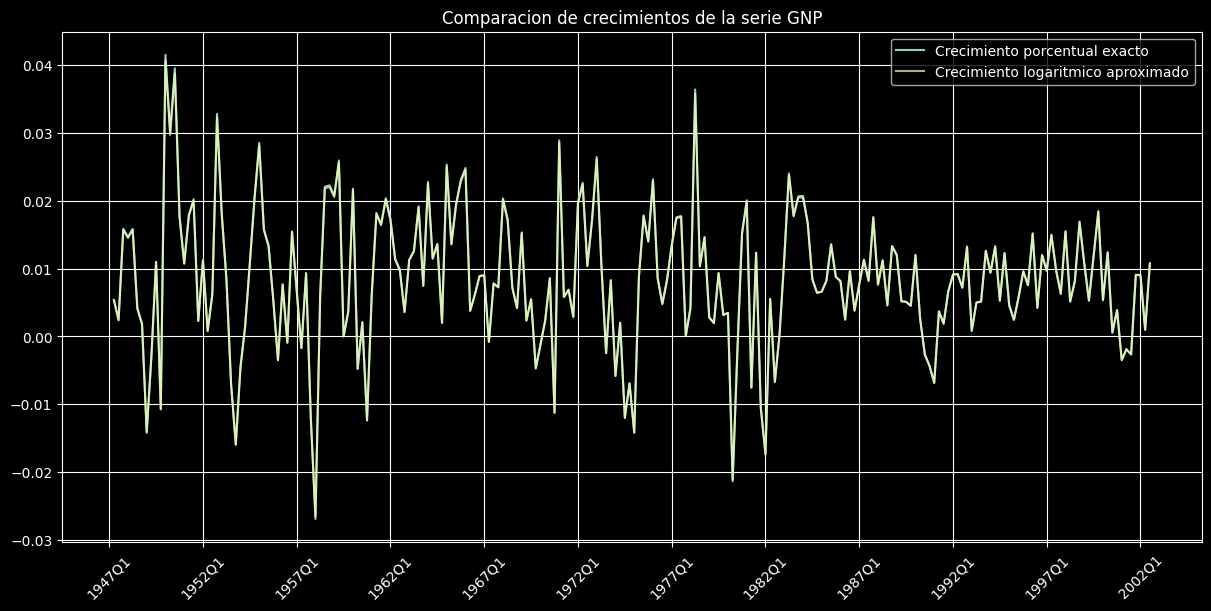

In [4]:
# Puntos 2, 3 y 4 del Ejercicio 1
crecimiento = (gnp - gnp.shift(1)) / gnp.shift(1)

# Como usamos pandas, calcular la diferencia logaritmica es sobre la serie, no los values
x = np.log(gnp).diff()

plt.figure(figsize=(12,6))
# Pasamos .values o la serie entera, y usamos el indice filtrado para el eje x
plt.plot(gnp_index_str, crecimiento, label='Crecimiento porcentual exacto')
plt.plot(gnp_index_str, x, label='Crecimiento logaritmico aproximado', alpha=0.7)

# Mismo filtrado para el eje x que en las celdas anteriores
plt.xticks(np.arange(0, len(gnp), 20), rotation=45)

plt.legend()
plt.title('Comparacion de crecimientos de la serie GNP')
plt.show()

In [5]:
# Calculamos la media y desviacion estandar de ambas series extrayendo el numero escalar
media_crecimiento = float(crecimiento.mean().iloc[0])
std_crecimiento = float(crecimiento.std().iloc[0])

media_x = float(x.mean().iloc[0])
std_x = float(x.std().iloc[0])

print(f"Crecimiento exacto      -> Media: {media_crecimiento:.5f}, Desviacion Estandar: {std_crecimiento:.5f}")
print(f"Crecimiento logaritmico -> Media: {media_x:.5f}, Desviacion Estandar: {std_x:.5f}")

Crecimiento exacto      -> Media: 0.00842, Desviacion Estandar: 0.01024
Crecimiento logaritmico -> Media: 0.00834, Desviacion Estandar: 0.01016


#### Respuesta 1.4: Comparación

Ambas series de crecimiento son muy similares casi indistinguibles. Esto se debe a que $\log(1+r) \approx r$ para $r$ chicos.

Ambas series transformadas se asemejan a ruido blanco. Esto  coincide con la definicion del modelo de proceso geometrico con ruido, ya que los incrementos logaritmicos de dicho modelo son estacionarios.

### Ejercicio 2

1. Considere la serie de datos `jj` de ganancias de Johnson y Johnson y sea $x_t = \log(jj_t)$. Aplique $x_t$ el siguiente filtro de media móvil:

    $$v_t = \frac{1}{4}(x_t + x_{t−1} + x_{t−2} + x_{t−3}).$$

    Grafique conjuntamente $x_t$ y $v_t$.

2. Comente el comportamiento de $x$ y $v$ y qué ocurre al aplicar el filtro. ¿Qué logra el filtro de media móvil? 

3. ¿Cómo lo aplicaría a los datos de Covid-19 que muestran ciclos semanales debido a los diferentes testeos diarios realizados?

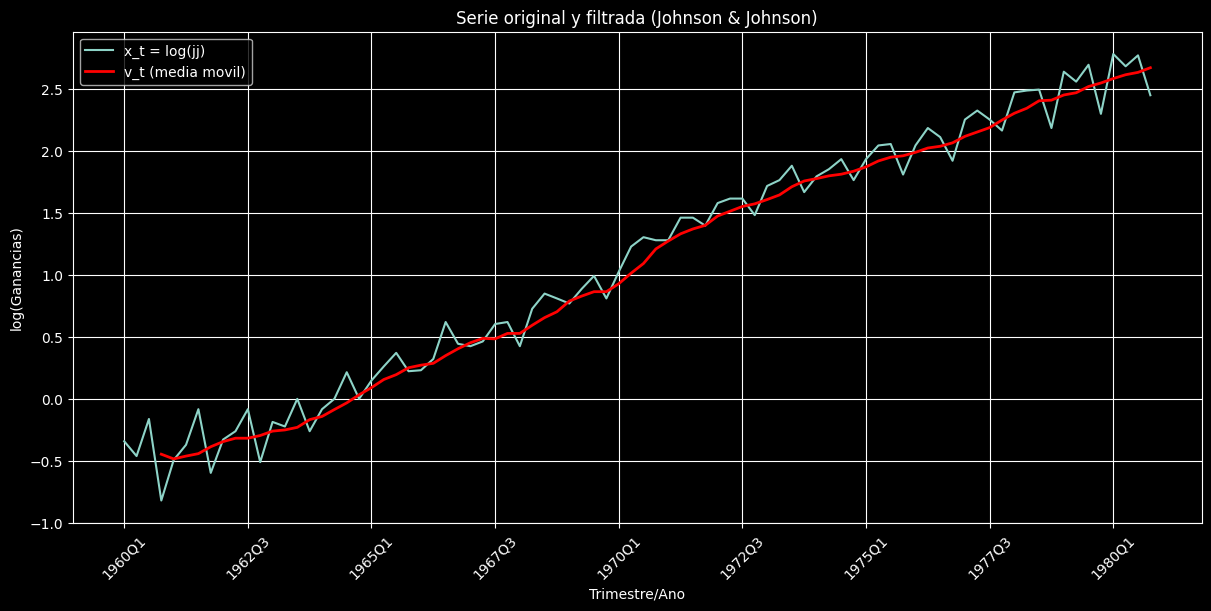

In [6]:
# 1. Aplicacion del filtro de media movil a la serie log(jj)
jj = astsa.jj.dropna()
x = np.log(jj)

# Filtro de media movil de orden 4
v = (x + x.shift(1) + x.shift(2) + x.shift(3)) / 4

plt.figure(figsize=(12,6))
plt.plot(x.index.astype(str), x.values, label='x_t = log(jj)')
plt.plot(x.index.astype(str), v, label='v_t (media movil)', color='red', linewidth=2)

# Filtrar ticks en eje X para no aglomerar etiquetas
plt.xticks(np.arange(0, len(x), 10), rotation=45)

plt.legend()
plt.title('Serie original y filtrada (Johnson & Johnson)')
plt.xlabel('Trimestre/Ano')
plt.ylabel('log(Ganancias)')
plt.show()


#### Respuestas 2.2 y 2.3

2. **Comportamiento y efecto del filtro:** La serie original $x_t$ presenta una clara y fuerte **estacionalidad trimestral** (picos recurrentes en los mismos trimestres de cada ano), ademas de una tendencia creciente. Al aplicar el filtro de media movil de 4 periodos ($v_t$), promediamos exactamente un año completo de datos. Esto suaviza la serie, **eliminando casi por completo la estacionalidad trimestral** y dejando a la vista unicamente la tendencia. El filtro de media movil logra asi aislar la tendencia, reduciendo la variabilidad de corto plazo.

3. **Aplicacion a datos de Covid-19:** Para los datos de Covid-19, la estacionalidad es semanal, donde ciertos dias de la semana sistematicamente reportan menos casos. Para remover este efecto de "dia de la semana" y ver la tendencia real, se deberia aplicar un **filtro de media movil de 7 dias**

### Ejercicio 3

Consideremos la serie temporal dada por:

$$x_t = \beta_0 + \beta_1 t + w_t,$$

con $\beta_0$ y $\beta_1$ coeficientes y $w_t$ es ruido blanco gaussiano de varianza $\sigma_w^2$.

1. Simule y grafique $n=100$ valores de esta serie, tomando $\beta_0=50$, $\beta_1=0.2$, $\sigma^2_w =9$, $t=(1,\ldots,100)$.

2. ¿La serie es estacionaria?

3. ¿Cómo podría estimar $\beta_0$ y $\beta_1$ a partir de las observaciones?

4. Mostrar que el proceso $y_t = x_t − x_{t−1}$ es estacionario. ¿Qué media tiene? Utilice el comando `diff`para calcular $y_t$ y graficarlo. Estimar su media y su autocorrelación y explique qué significan.

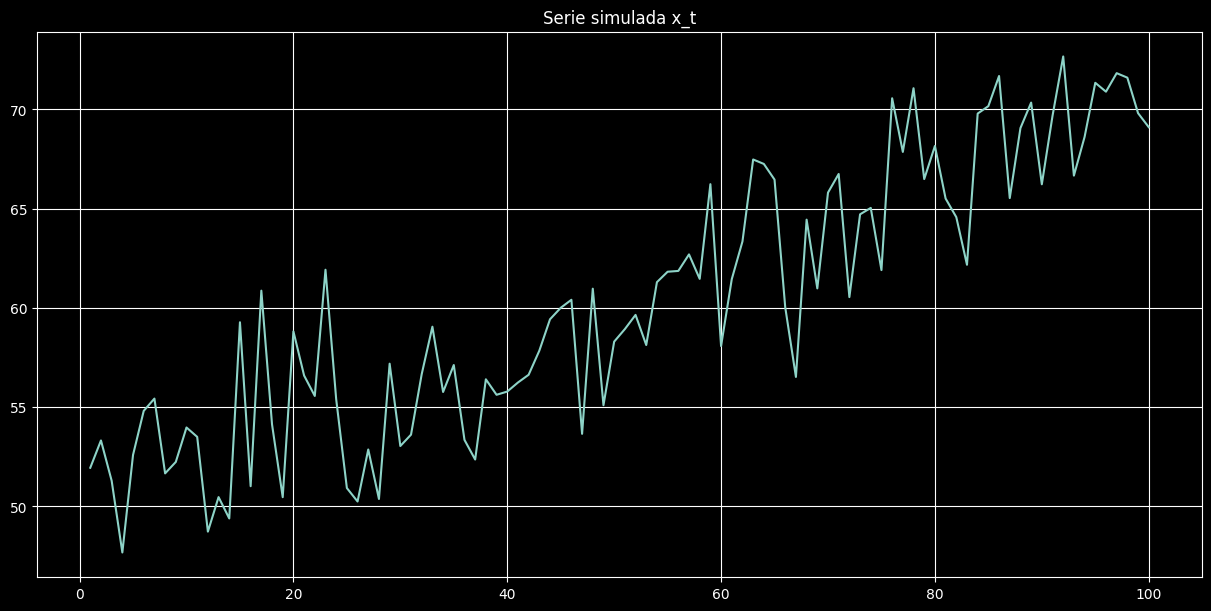

In [7]:
n = 100
t = np.arange(1, n+1)
beta0 = 50
beta1 = 0.2
sigma_w = 3  # sqrt(9)
w = np.random.normal(0, sigma_w, n)
x = beta0 + beta1 * t + w
plt.figure(figsize=(12,6))
plt.plot(t, x)
plt.title('Serie simulada x_t')
plt.show()

#### Respuesta 3.2

No es estacionaria, tiene una tendencia lineal.

#### Respuesta 3.3

Usando regresión lineal:

$x_t = \beta_0 + \beta_1 t + w_t$

#### Respuesta 3.4


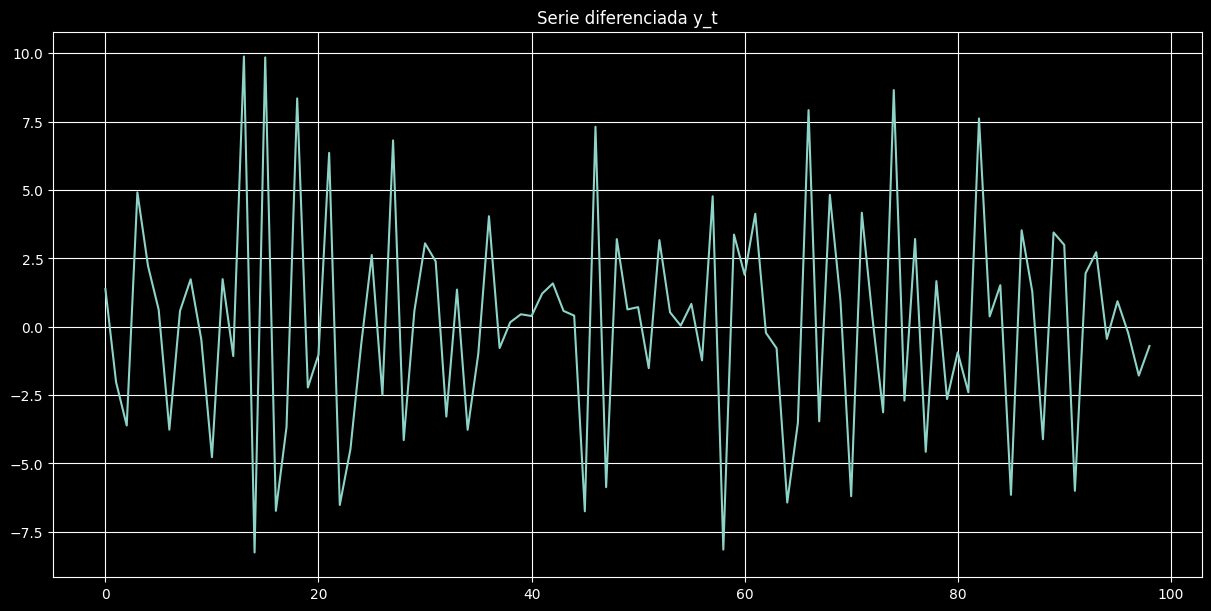

Media estimada: 0.173


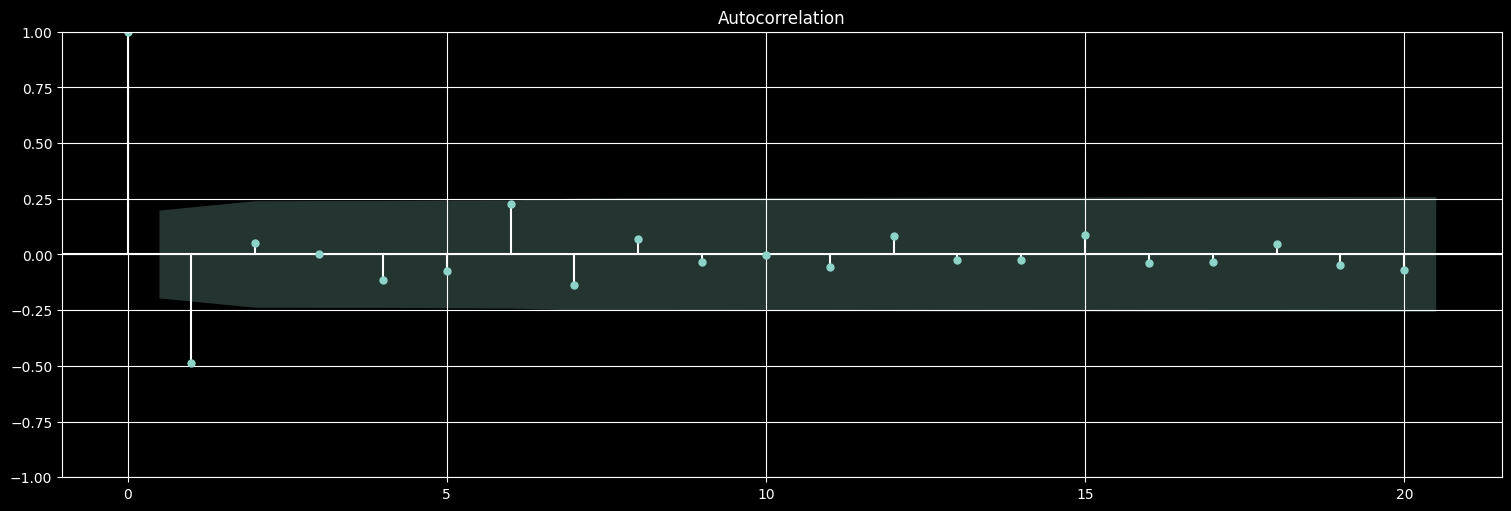

In [8]:
y = np.diff(x)
plt.figure(figsize=(12,6))
plt.plot(y)
plt.title('Serie diferenciada y_t')
plt.show()
print(f'Media estimada: {np.mean(y):.3f}')
# Autocorrelación
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(y, lags=20)
plt.show()

El ACF muestra un pico negativo significativo en lag 1 (≈ −0.5) y corte abrupto para lags mayores.

$$x_t = 0.2 + w_t - w_{t-1}$$
$$x_{t+1} = 0.2 + w_{t+1} - w_t$$
$$\text{Cov}(x_t, x_{t+1}) \neq 0 \text{ porque ambas comparten } w_t \text{ con signos opuestos}$$
$$\Rightarrow \rho(1) = \frac{-\sigma_w^2}{2\sigma_w^2} = -0.5$$

Media Estimada

$$ = 0.198≈β1$$

## Análisis exploratorio de series

### Ejercicio 4:

Consideremos la serie $y_t$ de ganancias de Johnson & Johnson almacenada en `jj`. Se realiza la transformación $x_t = \log(y_t)$. Dicha transformación muestra los incrementos relativos o porcentuales (al pasar a logaritmo).

1. Ajustar un modelo de la forma:
$$x_t = \beta_0 t + \sum_{i=1}^4 \beta_i Q_i(t) + w_t$$
siendo $Q_i$ una función que vale $1$ si se está en el trimestre $i$ y $0$ si no.

    *Sugerencia:* construir $Q_i$ usando vectores de la forma $(1,0,0,0)$, $(0,1,0,0)$ etc. repetidos adecuadamente.

2. Graficar los datos y superponer los datos ajustados.

3. Calcular los residuos y evaluar el ajuste.

#### Respuesta 4.1

In [9]:
x = np.log(astsa.jj.values).flatten()
n = len(x)
t = np.arange(1, n+1)
# Crear Q_i
Q1 = np.tile([1,0,0,0], n//4 + 1)[:n]
Q2 = np.tile([0,1,0,0], n//4 + 1)[:n]
Q3 = np.tile([0,0,1,0], n//4 + 1)[:n]
Q4 = np.tile([0,0,0,1], n//4 + 1)[:n]

df = pd.DataFrame({'t': t, 'Q1': Q1, 'Q2': Q2, 'Q3': Q3, 'Q4': Q4, 'x': x})
model = smf.ols('x ~ t + Q1 + Q2 + Q3 + Q4 -1', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      x   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     1379.
Date:                Fri, 15 May 2026   Prob (F-statistic):           3.33e-72
Time:                        05:14:58   Log-Likelihood:                 57.808
No. Observations:                  84   AIC:                            -105.6
Df Residuals:                      79   BIC:                            -93.46
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
t              0.0418      0.001     73.999      0.0

#### Respuesta 4.2

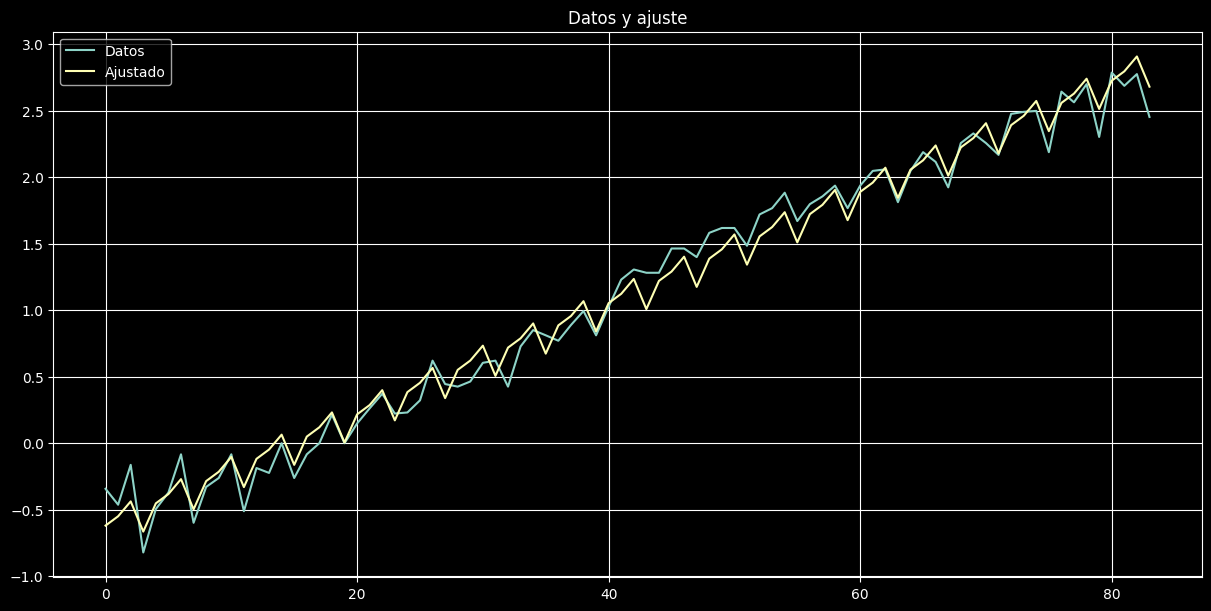

In [10]:
fitted = model.fittedvalues
plt.figure(figsize=(12,6))
plt.plot(x, label='Datos')
plt.plot(fitted, label='Ajustado')
plt.legend()
plt.title('Datos y ajuste')
plt.show()

#### Respuesta 4.3

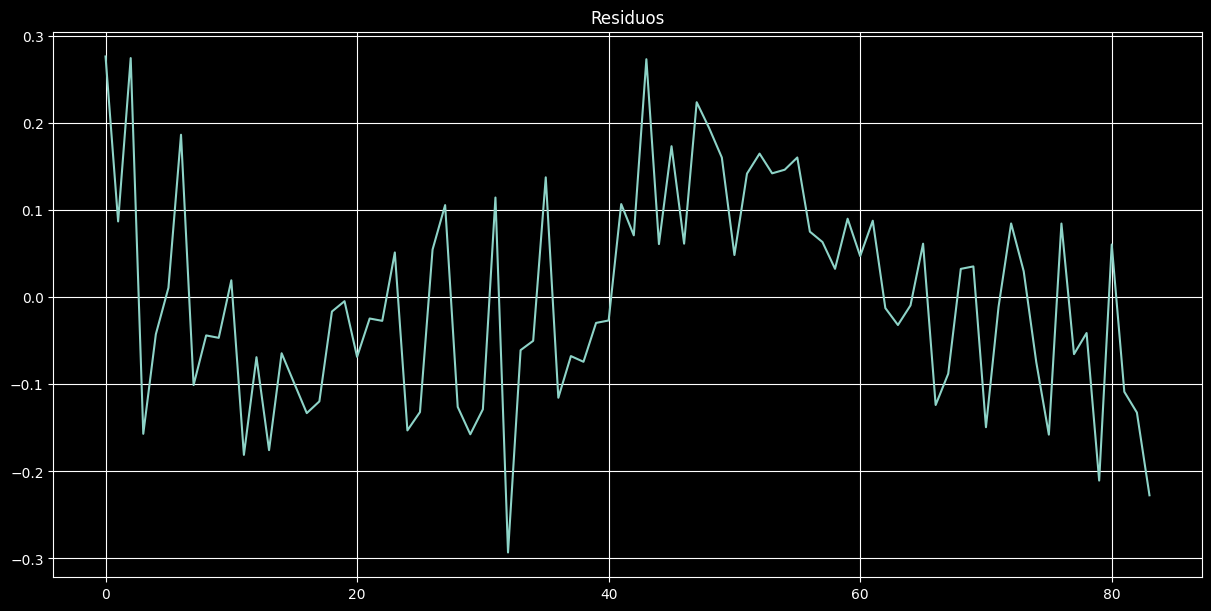

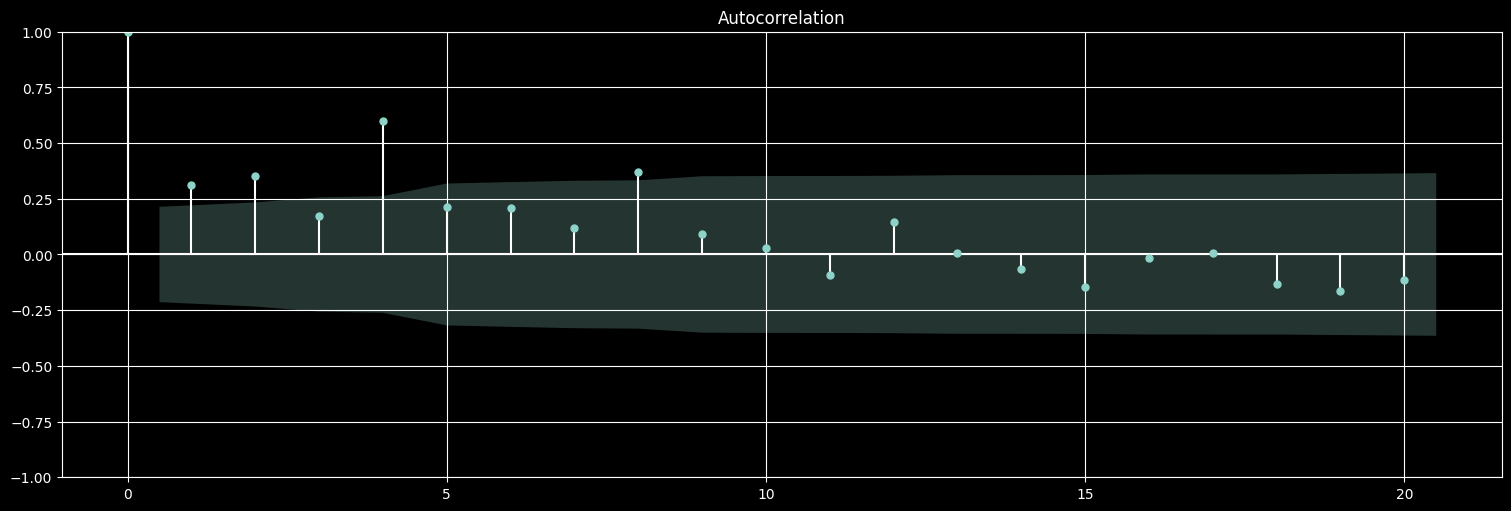

In [11]:
residuos = model.resid
plt.figure(figsize=(12,6))
plt.plot(residuos)
plt.title('Residuos')
plt.show()
plot_acf(residuos, lags=20)
plt.show()

Los residuos no son ruido blanco: el ACF muestra un pico en lag 4 (1 año para atras en trimestres), lo que indica que el modelo no captura completamente la estructura estacional.

### Ejercicio 5

En este ejercicio, se busca explorar la naturaleza periódica de $S_t$, la serie SOI ya analizada.

1. Quitar la tendencia a las serie mediante una regresión lineal en la componente tiempo. ¿Hay una tendencia significativa en la temperatura de superficie?

2. Calcular el periodograma para la serie sin tendencia (residuos) de la parte anterior. Identificar las frecuencias principales (una obvia es la anual). ¿Cuál es el ciclo probable del fenómeno del Niño que refleja el segundo pico más alto?


#### Respuesta 5.1

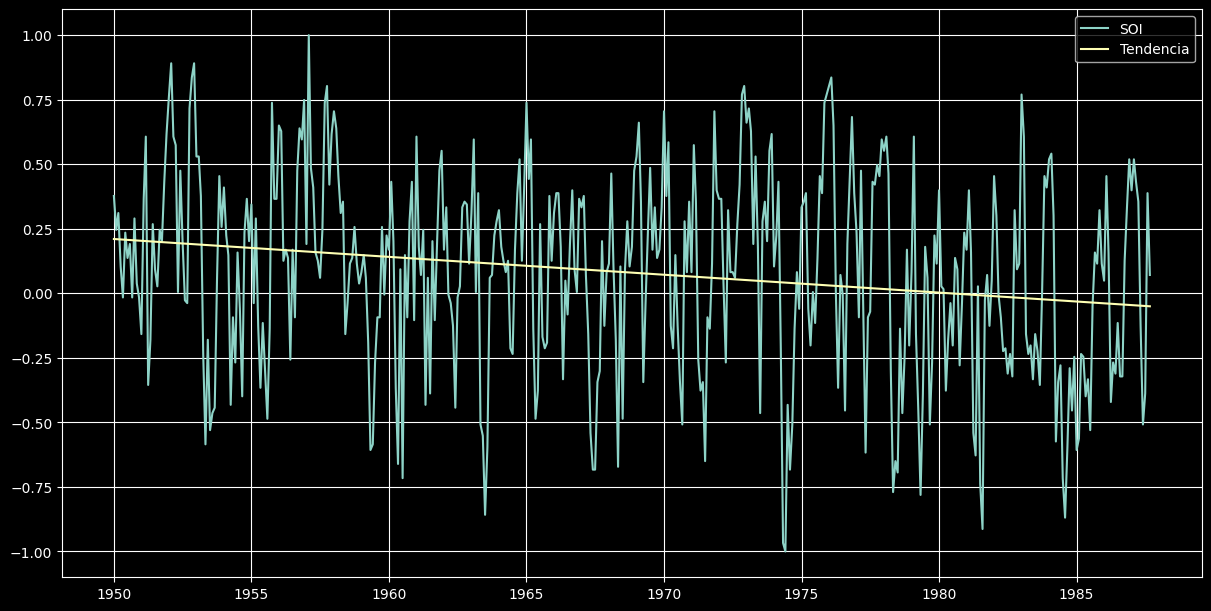

                            OLS Regression Results                            
Dep. Variable:                  value   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                     18.25
Date:                Fri, 15 May 2026   Prob (F-statistic):           2.36e-05
Time:                        05:18:49   Log-Likelihood:                -198.24
No. Observations:                 453   AIC:                             400.5
Df Residuals:                     451   BIC:                             408.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2109      0.035      5.966      0.0

In [15]:
soi = astsa.soi
n = len(soi)
t = np.arange(1, n+1)
X = sm.add_constant(t)
model = sm.OLS(soi, X).fit()
residuos = model.resid
plt.figure(figsize=(12,6))
plt.plot(soi.index.to_timestamp(), soi.values, label='SOI')
plt.plot(model.fittedvalues.index.to_timestamp(), model.fittedvalues.values, label='Tendencia')
plt.legend()
plt.show()
print(model.summary())

Se observa una tendencia significativa aunque con coeficiente pequeño (0.0006)

#### Respuesta 5.2

In [17]:
def periodogram(x,sampling_frequency=1):

    """Función que calcula el periodograma y grafica.
    
    Parameters
    ----------
        x : array_like, data.
        sampling_frequency: frecuencia de muestreo de la serie, para graficar.
    """

    n = x.size
    P = 4/n**2 * np.abs(np.fft.fft(x))**2
    P = P[0:round(n/2)]
    f = np.arange(0,round(n/2))/n * sampling_frequency
    plt.stem(f,P,basefmt='');
    plt.xlabel("Frequency")
    plt.ylabel("Power")

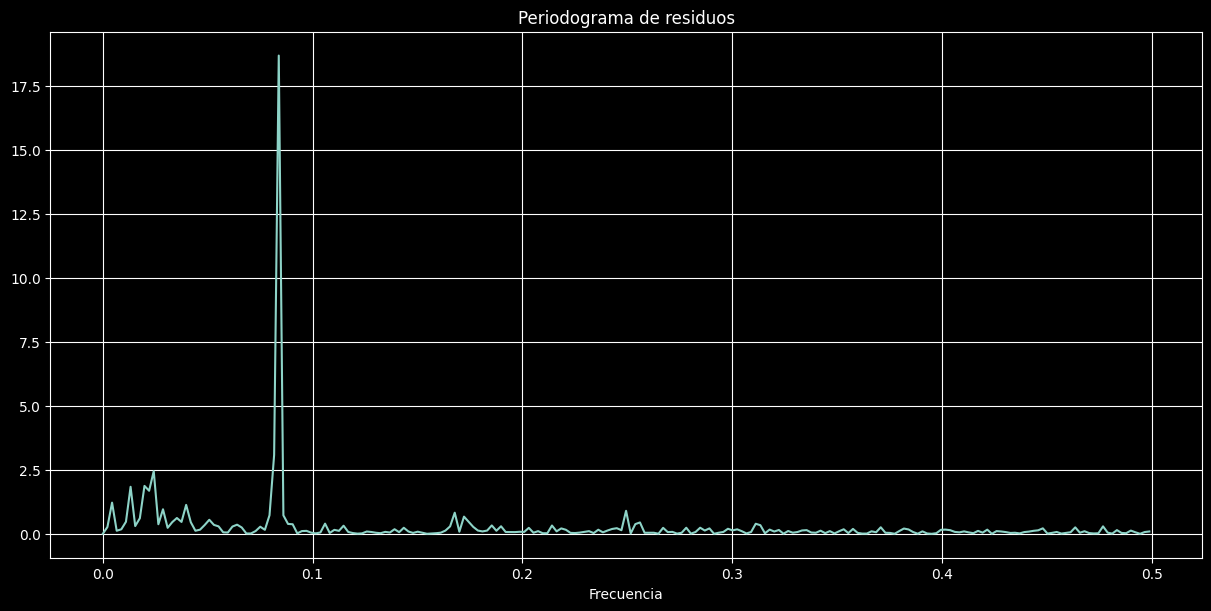

In [16]:
from scipy.signal import periodogram
freq, power = periodogram(residuos)
plt.figure(figsize=(12,6))
plt.plot(freq, power)
plt.title('Periodograma de residuos')
plt.xlabel('Frecuencia')
plt.show()
# Frecuencia anual: 1/12 ≈ 0.083
# Segundo pico: alrededor de 1/4 años o similar

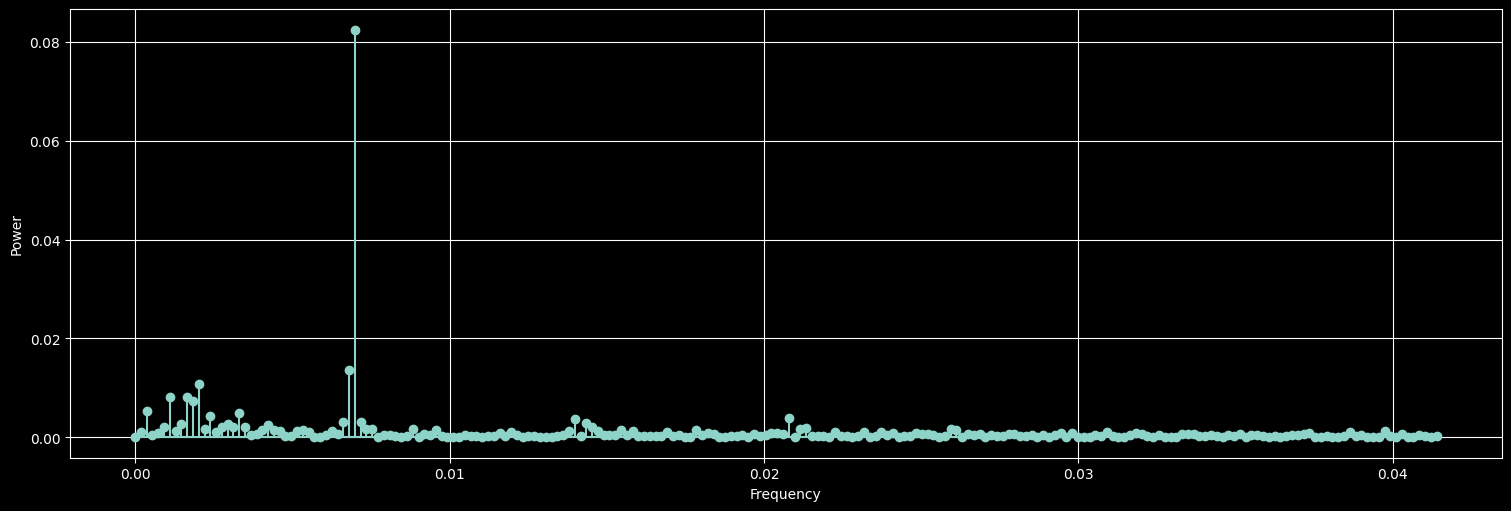

In [ ]:
periodogram(residuos)

In [20]:
def spectrum(x,sampling_frequency=1, nfreq=10):

    """Función que calcula las componentes más relevantes del periodograma.
    
    Parameters
    ----------
        x : array_like, data.
        sampling_frequency: frecuencia de muestreo de la serie, para graficar.
    """

    n = x.size
    nfreq = np.minimum(nfreq,round(n/2)) #corto nfreq si la serie es muy corta!
    P = 4/n**2 * np.abs(np.fft.fft(x))**2
    P = P[0:round(n/2)]
    f = np.arange(0,round(n/2))/n * sampling_frequency
    index = np.argsort(P)[::-1] #ordeno P decreciente
    return pd.DataFrame({"Frecuencia" : f[index[0:nfreq]],"Potencia" : P[index[0:nfreq]]})

In [22]:
spectrum(residuos, nfreq=20)

,Frecuencia,Potencia
0,0.083885,0.082421
1,0.081678,0.013601
2,0.024283,0.010792
3,0.019868,0.008258
4,0.013245,0.008103
5,0.022075,0.007418
6,0.004415,0.005376
7,0.039735,0.004985
8,0.028698,0.004228
9,0.249448,0.003964


El periodograma muestra un pico claro en 0.083 de aprox 0.082
0.083 representa un ciclo anual. Ademas se observa una zona de picos menores concentrada en frecuencias bajas asociada al ciclo del Niño.

| Frecuencia | Período | Interpretación |
|---|---|---|
| $f \approx 0.0839$ | $\approx 12$ meses | Ciclo anual |
| $f \approx 0.0243$ | $\approx 41$ meses $\approx 3.4$ años | Ciclo del Niño |

### Ejercicio 6

Considere las dos series semanales `oil` (precio del petróleo) and `gas` (precio del combustible). La primera está en dólares por barril, la segunda en centavos por galón.

1. Graficar ambas en una misma gráfica. ¿Cuál de los modelos ya vistos se asemeja más? ¿Son estacionarias?

2. En economía, muchas veces la información se encuentra en el porcentaje de cambio de la serie (retorno o tasa de crecimiento). Argumente que la transformación $y_t= \log(x_t) - \log(x_{t-1})$ puede usarse para obtener el retorno.

3. Aplicar la transformación a las series anteriores, volver a graficar y analizar la autocorrelación de las mismas.

4. Graficar la correlación cruzada de las series transformadas. Los valores pequeños pero significativos donde gas adelanta a oil pueden ser considerados "realimentación" entre ellas.

5. Realizar nubes de puntos para las series laggeadas, con hasta 3 semanas de diferencia.

6. Hay estudios que afirman que los precios de combustible responden más rápido a las subidas del petróleo que a las bajadas. Para explorar esto hagamos una regresión con lags simple. 

   Sean $G_t$ y $O_t$ las series transformadas de gas y oil respectivamente. Ajuste una regresión:

    $$G_t = \alpha_1 + \alpha_2 I_t + \beta_1 O_t + \beta_2 O_{t−1} + w_t,$$

   siendo $I_t = 1$ si $O_t \geqslant 0$ y $0$ si no ($I_t$ representa si oil está creciendo). 
   
   Analizar y discutir los resultados.

#### Respuesta 6.1

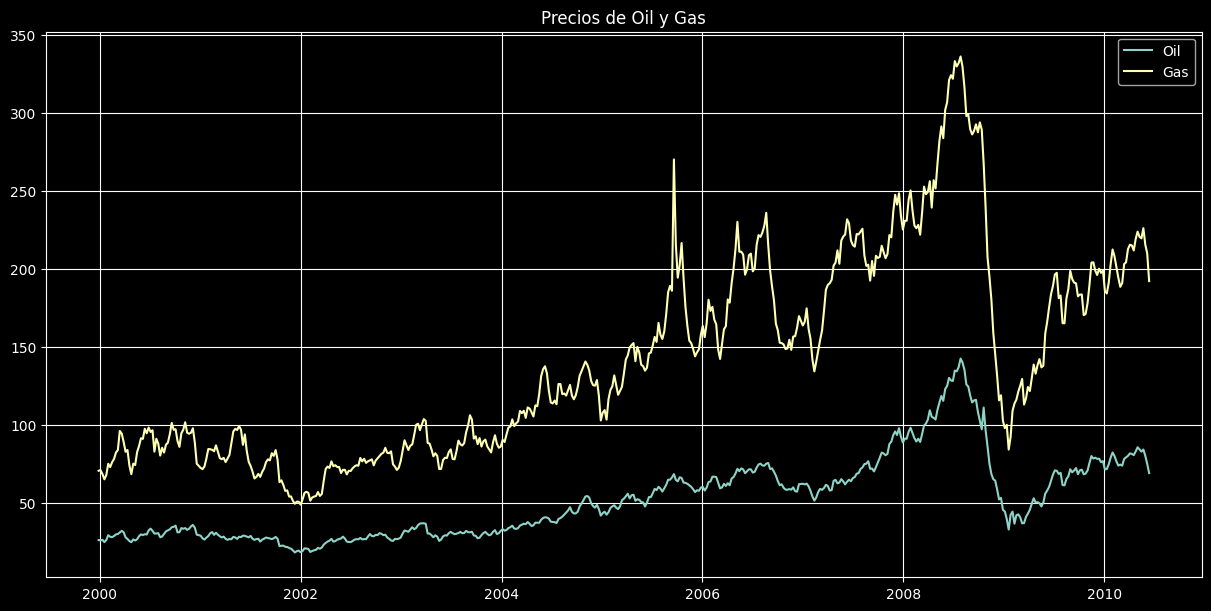

In [24]:
plt.figure(figsize=(12,6))
plt.plot(astsa.oil.index.to_timestamp(), astsa.oil.values, label='Oil')
plt.plot(astsa.gas.index.to_timestamp(), astsa.gas.values, label='Gas')
plt.legend()
plt.title('Precios de Oil y Gas')
plt.show()

No son estacionarias, se asemeja a un proceso geométrico con ruido, al igual que el ejercicio 1.1

#### Respuesta 6.2

El retorno $r_t$ representa el cambio porcentual del precio entre dos períodos consecutivos:

$$r_t = \frac{x_t - x_{t-1}}{x_{t-1}}$$

Dado que $\log\left(\frac{x_t}{x_{t-1}}\right) = \log(1 + r_t) \approx r_t$ para retornos pequeños, la transformación log-diff es una aproximación del retorno porcentual.

#### Respuesta 6.3

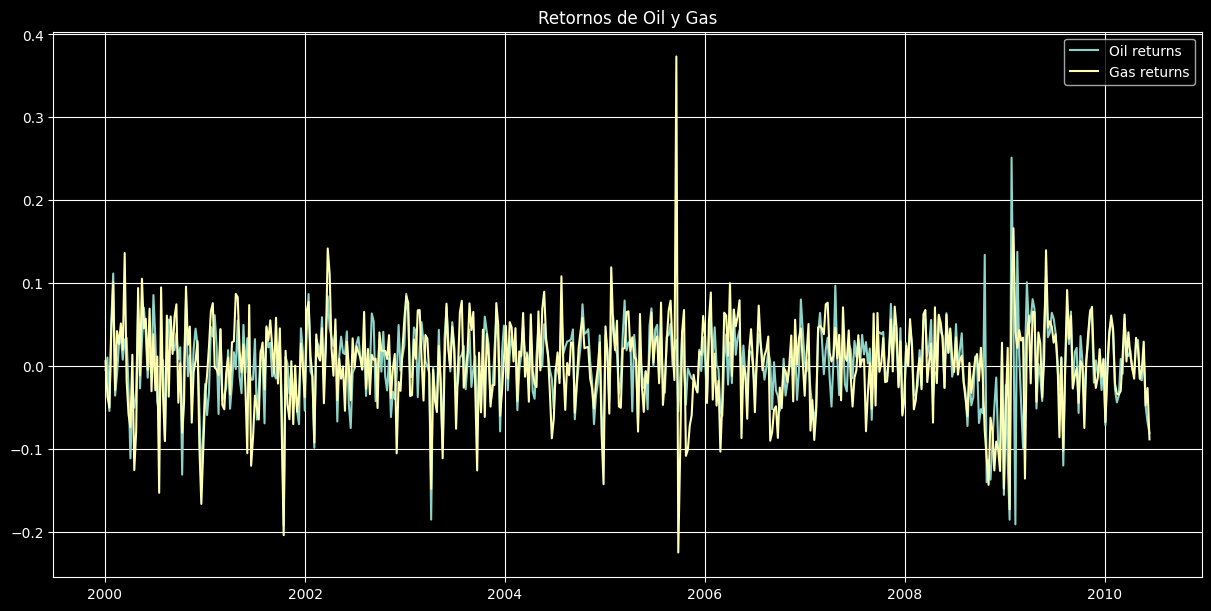

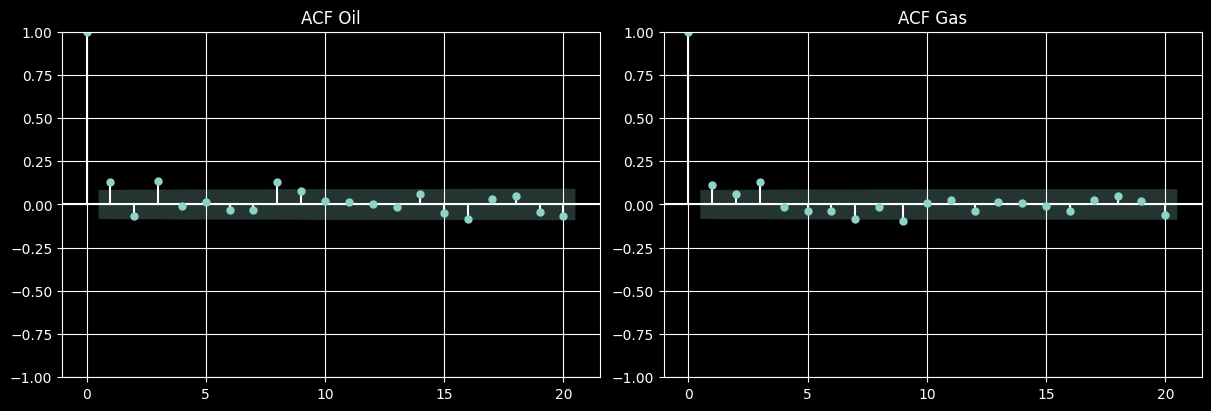

In [25]:
oil_ret = np.log(astsa.oil).diff().dropna()
gas_ret = np.log(astsa.gas).diff().dropna()

plt.figure(figsize=(12,6))
plt.plot(oil_ret.index.to_timestamp(), oil_ret.values, label='Oil returns')
plt.plot(gas_ret.index.to_timestamp(), gas_ret.values, label='Gas returns')
plt.legend()
plt.title('Retornos de Oil y Gas')
plt.show()

# ACF
fig, axes = plt.subplots(1, 2, figsize=(12,4))
plot_acf(oil_ret, lags=20, ax=axes[0], title='ACF Oil')
plot_acf(gas_ret, lags=20, ax=axes[1], title='ACF Gas')
plt.show()

Luego de aplicar la transformacion, ambas series de retornos se comportan aproximadamente como **ruido blanco**. Se observan picos pequeños en lags 1 y 2 que rozan las bandas de confianza, sugiriendo una autocorrelación débil de corto plazo. Esto implica que el retorno de una semana tiene escasa capacidad predictiva sobre el retorno de la semana siguiente.

#### Respuesta 6.4

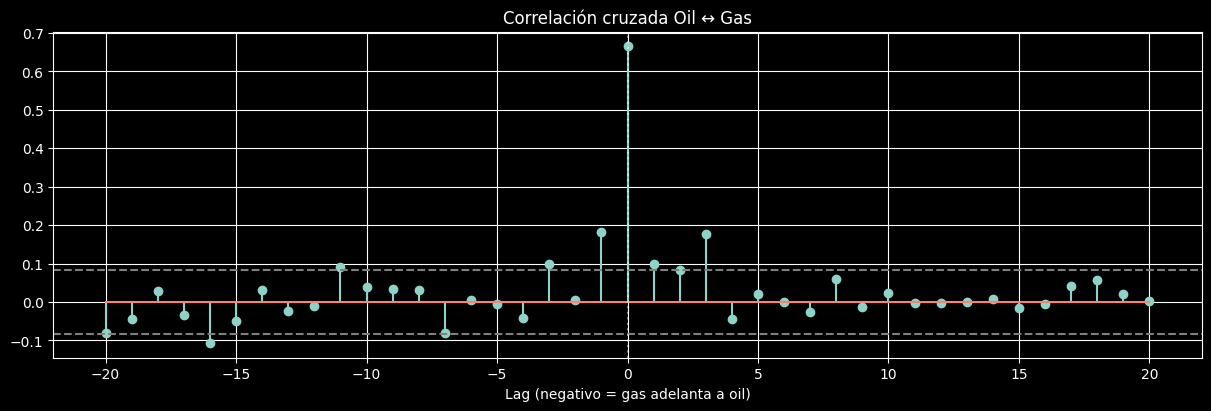

In [29]:
from statsmodels.tsa.stattools import ccf

# CCF: oil vs gas
cc = ccf(oil_ret.values.flatten(), gas_ret.values.flatten(), adjusted=False)
lags = np.arange(-20, 21)
cc_both = np.concatenate([ccf(gas_ret.values.flatten(), oil_ret.values.flatten(), adjusted=False)[1:21][::-1], 
                           cc[:21]])

plt.figure(figsize=(12,4))
plt.stem(lags, cc_both)
plt.axhline(1.96/np.sqrt(len(oil_ret)), color='gray', linestyle='--')
plt.axhline(-1.96/np.sqrt(len(oil_ret)), color='gray', linestyle='--')
plt.axvline(0, color='white', linestyle=':', alpha=0.5)
plt.title('Correlación cruzada Oil ↔ Gas')
plt.xlabel('Lag (negativo = gas adelanta a oil)')
plt.show()

La correlación cruzada muestra una correlación contemporánea fuerte (lag 0 ≈ 0.67), indicando que ambas series se mueven juntas en la misma semana. En lags positivos se observa el pico más significativo en lag 3, lo que sugiere que el precio del petróleo predice el precio del combustible con aproximadamente 3 semanas de adelanto. En lags negativos, el pico en lag -1 es también significativo, lo que indica que el precio del gas de la semana anterior tiene capacidad predictiva sobre el precio del petróleo — esto es la "realimentación" mencionada en el enunciado, donde gas adelanta a oil.

#### Respuesta 6.5

C:\Users\joaquin.guerra\AppData\Local\Temp\ipykernel_13808\2237671302.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


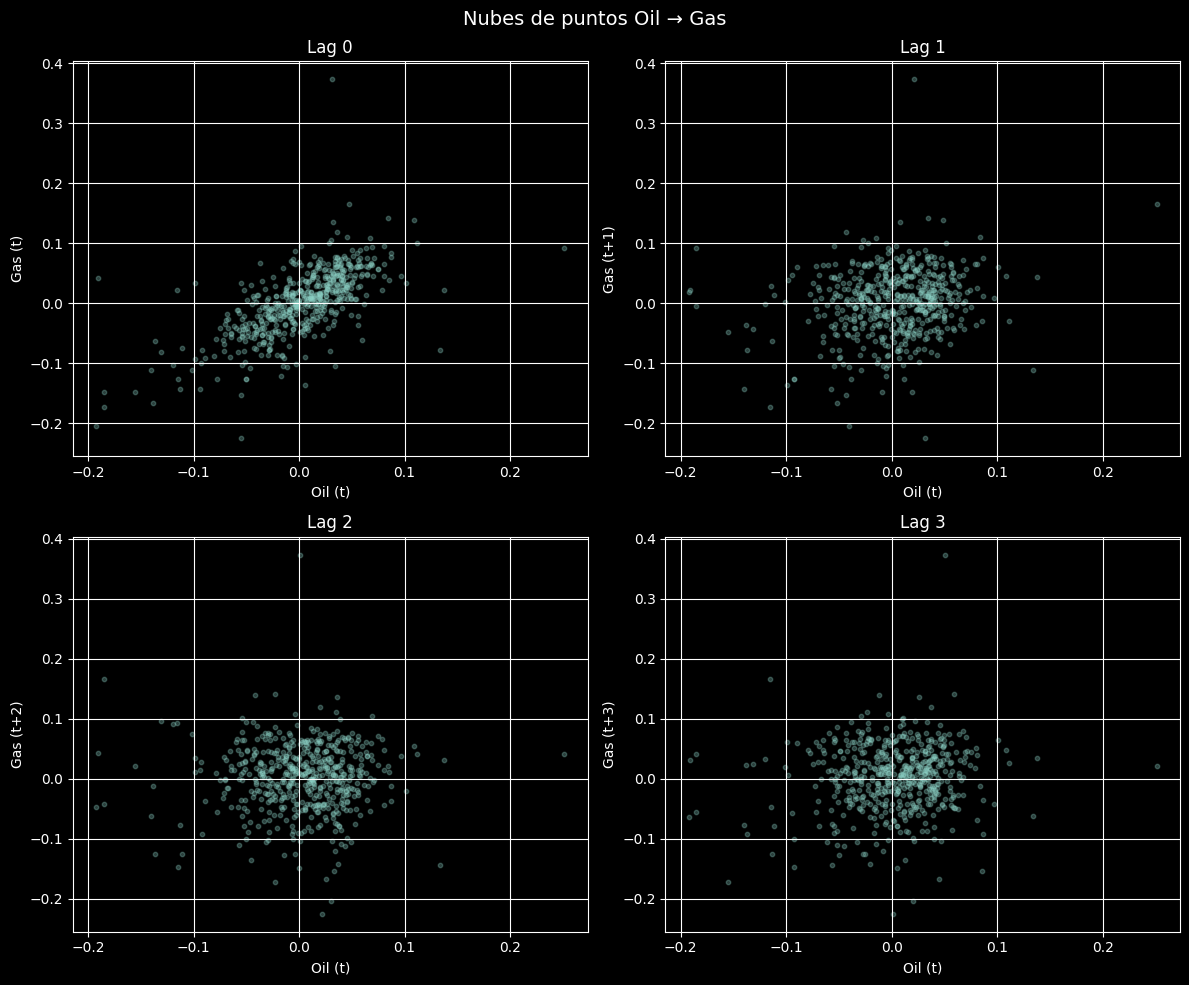

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for lag in range(4):
    if lag == 0:
        axes[lag].scatter(oil_ret.values, gas_ret.values, alpha=0.3, s=10)
        axes[lag].set_xlabel('Oil (t)')
        axes[lag].set_ylabel('Gas (t)')
        axes[lag].set_title('Lag 0')
    else:
        axes[lag].scatter(oil_ret.values[:-lag], gas_ret.values[lag:], alpha=0.3, s=10)
        axes[lag].set_xlabel('Oil (t)')
        axes[lag].set_ylabel(f'Gas (t+{lag})')
        axes[lag].set_title(f'Lag {lag}')

plt.suptitle('Nubes de puntos Oil → Gas', fontsize=14)
plt.tight_layout()
plt.show()

Las nubes de puntos confirman lo observado en la correlación cruzada. En lag 0 se observa una relación lineal positiva clara entre los retornos de oil y gas. A medida que aumenta el lag la estructura se va diluyendo, aunque la CCF sugiere que en lag 3 persiste una correlación levemente mayor que en lags 1 y 2, diferencia que no es fácilmente perceptible a simple vista en las nubes de puntos dado que las correlaciones son pequeñas.

In [37]:
G = gas_ret.values.flatten()
O = oil_ret.values.flatten()

G = G[1:]
O_t = O[1:]
O_lag = O[:-1]
I_t = (O_t >= 0).astype(int)

df_reg = pd.DataFrame({
    'G': G,
    'O': O_t,
    'O_lag': O_lag,
    'I': I_t
})

model = smf.ols('G ~ I + O + O_lag', data=df_reg).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      G   R-squared:                       0.456
Model:                            OLS   Adj. R-squared:                  0.453
Method:                 Least Squares   F-statistic:                     150.8
Date:               vi., 15 may. 2026   Prob (F-statistic):           6.11e-71
Time:                        06:20:26   Log-Likelihood:                 956.85
No. Observations:                 543   AIC:                            -1906.
Df Residuals:                     539   BIC:                            -1889.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0064      0.003     -1.860      0.0

El modelo explica el 45.6% de la varianza de los retornos de gas ($R^2 = 0.456$). El coeficiente de I = 0.0124 es positivo y significativo (p = 0.025), confirmando la hipótesis: los precios del combustible responden más fuerte ante subidas del petróleo que ante bajadas. El efecto contemporáneo = 0.683 es el dominante, y el correspondiente al valor anterior de oil = 0.112 indica que el efecto se extiende al menos una semana.